In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras.initializers import RandomNormal, GlorotUniform, HeNormal
import matplotlib.pyplot as plt

In [ ]:
# Load MNIST dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normalize
# X_train = X_train / 255.0
# X_test = X_test / 255.0

X_train_small = X_train[:10000]
y_train_small = y_train[:10000]

X_test_small = X_test[:2000]
y_test_small = y_test[:2000]


**Model Architecture**

In [ ]:
def create_model(weight_init, optimizer):
    model = Sequential([
        Flatten(input_shape=(28, 28)),
        Dense(128, activation='relu', kernel_initializer=weight_init),
        Dense(64, activation='relu', kernel_initializer=weight_init),
        Dense(10, activation='softmax', kernel_initializer=weight_init)
    ])

    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

**Configurations**

In [ ]:
initializations = {
    "Random Normal": RandomNormal(mean=0.0, stddev=0.05),
    "Xavier (Glorot)": GlorotUniform(),
    "He Normal": HeNormal()
}

# optimizers = {
#     "SGD": SGD(learning_rate=0.01),
#     "Adam": Adam(learning_rate=0.001)
# }

optimizers = {
    "SGD": lambda: tf.keras.optimizers.SGD(learning_rate=0.01),
    "Adam": lambda: tf.keras.optimizers.Adam(learning_rate=0.001)
}


#EPOCHS = 10
EPOCHS = 3

**Training Models & Collecting Results**

In [ ]:
# history_records = {}

# tf.config.run_functions_eagerly(True)

# for init_name, init in initializations.items():
#     for opt_name, opt_instance in optimizers.items():
#         print(f"\nTraining with {init_name} + {opt_name}")

#         # Create a new optimizer instance for each model
#         # by getting its class and configuration, then recreating it.
#         opt_class = type(opt_instance)
#         opt_config = opt_instance.get_config()
#         new_optimizer = opt_class.from_config(opt_config)

#         model = create_model(init, new_optimizer)
#         history = model.fit(
#             X_train, y_train,
#             validation_data=(X_test, y_test),
#             epochs=EPOCHS,
#             batch_size=128,
#             verbose=1
#         )

#         history_records[f"{init_name} + {opt_name}"] = history

history_records = {}

for init_name, init in initializations.items():
    for opt_name, opt_fn in optimizers.items():
        print(f"\nTraining with {init_name} + {opt_name}")

        model = create_model(init, opt_fn())

        history = model.fit(
            X_train_small, y_train_small,
            validation_data=(X_test_small, y_test_small),
            epochs=EPOCHS,
            batch_size=128,
            verbose=1
        )

        history_records[f"{init_name} + {opt_name}"] = history

        # Clear session AFTER training each model
        tf.keras.backend.clear_session()



Training with Random Normal + SGD
Epoch 1/3
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.4234 - loss: 11.6837 - val_accuracy: 0.5940 - val_loss: 1.9244
Epoch 2/3
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.7939 - loss: 0.7072 - val_accuracy: 0.8010 - val_loss: 0.6241
Epoch 3/3
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.8676 - loss: 0.4173 - val_accuracy: 0.8310 - val_loss: 0.5547

Training with Random Normal + Adam
Epoch 1/3
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.5770 - loss: 4.6258 - val_accuracy: 0.8060 - val_loss: 0.7013
Epoch 2/3
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - accuracy: 0.8982 - loss: 0.3516 - val_accuracy: 0.8655 - val_loss: 0.5106
Epoch 3/3
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.9333 - loss: 0.2207 - val_accuracy: 0.8780 - val_loss: 0.4493

Training with Xavier (Glorot) + SGD
Epoch 1/3
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.0994 - loss: 4353107271853539328.0000 - val_accuracy: 0.1175 - val_loss

**Training Loss Graph**

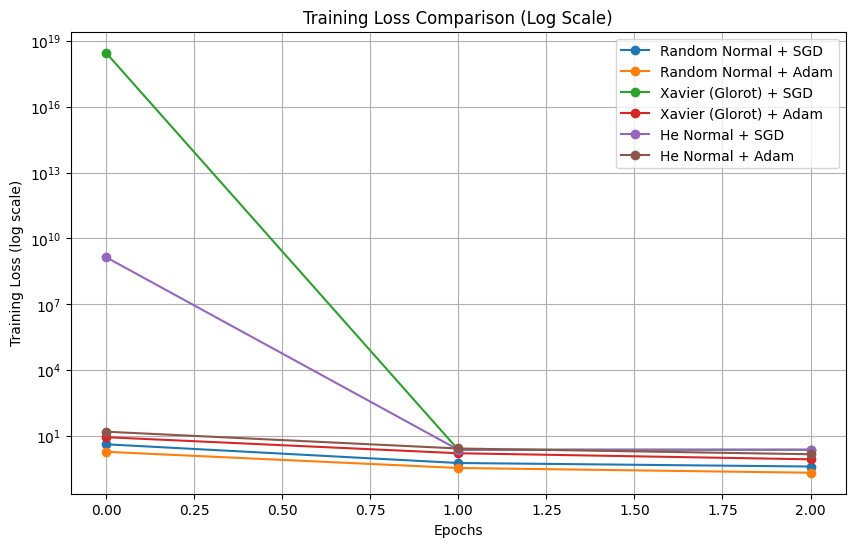

In [ ]:
# plt.figure(figsize=(10, 6))

# for key, history in history_records.items():
#     plt.plot(history.history['loss'], label=key)

# plt.xlabel("Epochs")
# plt.ylabel("Training Loss")
# plt.title("Training Loss Comparison")
# plt.legend()
# plt.show()

plt.figure(figsize=(10, 6))

for key, history in history_records.items():
    plt.plot(history.history['loss'], marker='o', label=key)

plt.xlabel("Epochs")
plt.ylabel("Training Loss (log scale)")
plt.yscale("log")          # ✅ THIS LINE FIXES IT
plt.title("Training Loss Comparison (Log Scale)")
plt.legend()
plt.grid(True)
plt.show()


**Training Accuracy Graph**

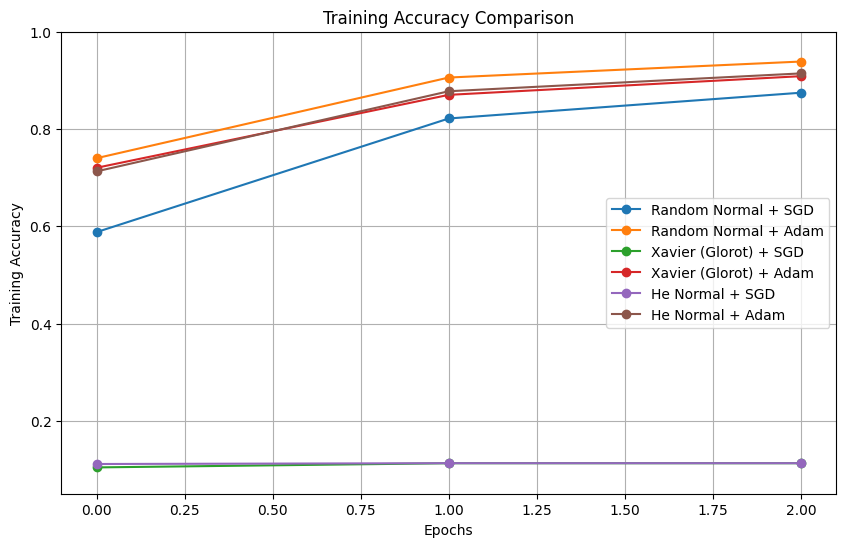

In [ ]:
# plt.figure(figsize=(10, 6))

# for key, history in history_records.items():
#     plt.plot(history.history['accuracy'], label=key)

# plt.xlabel("Epochs")
# plt.ylabel("Training Accuracy")
# plt.title("Training Accuracy Comparison")
# plt.legend()
# plt.show()

plt.figure(figsize=(10, 6))

for key, history in history_records.items():
    plt.plot(history.history['accuracy'], marker='o', label=key)

plt.xlabel("Epochs")
plt.ylabel("Training Accuracy")
plt.ylim(0.05, 1.0)        # ✅ zoom so low-accuracy lines are visible
plt.title("Training Accuracy Comparison")
plt.legend()
plt.grid(True)
plt.show()


**Final Test Accuracy Output**

In [ ]:
print("\nFinal Test Accuracies :")
for key, history in history_records.items():
    final_acc = history.history['val_accuracy'][-1]
    print(f"{key} : {final_acc:.4f}")


Final Test Accuracies :
Random Normal + SGD : 0.8310
Random Normal + Adam : 0.8780
Xavier (Glorot) + SGD : 0.1175
Xavier (Glorot) + Adam : 0.8530
He Normal + SGD : 0.1170
He Normal + Adam : 0.8405


**Final Accuracy Table (Validation Accuracy)**

In [ ]:
import pandas as pd

final_results = []

for key, history in history_records.items():
    final_train_acc = history.history['accuracy'][-1]
    final_val_acc = history.history['val_accuracy'][-1]

    final_results.append({
        "Initialization + Optimizer": key,
        "Final Training Accuracy": round(final_train_acc, 4),
        "Final Validation Accuracy": round(final_val_acc, 4)
    })

results_df = pd.DataFrame(final_results)
results_df
print(results_df.to_string(index=False))

Initialization + Optimizer  Final Training Accuracy  Final Validation Accuracy
       Random Normal + SGD                   0.8746                     0.8310
      Random Normal + Adam                   0.9387                     0.8780
     Xavier (Glorot) + SGD                   0.1127                     0.1175
    Xavier (Glorot) + Adam                   0.9086                     0.8530
           He Normal + SGD                   0.1128                     0.1170
          He Normal + Adam                   0.9143                     0.8405
